<a href="https://colab.research.google.com/github/harsh123-dev/EDA-Course-Project/blob/main/EDA_Phase_1_and_Phase_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA Course Project – Phase 1

## Exploratory Data Analysis on the BEPS Dataset

This notebook completes the required Phase 1 tasks:

1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis – minimum 3 visualizations
7. Bivariate analysis – minimum 3 visualizations
8. Multivariate analysis – minimum 3 visualizations

The analysis is descriptive and focuses on the structure, distributions, and relationships present in the dataset.


## 1. Import Libraries


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110


## 2. Loading the Dataset


In [2]:
dataset_url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/BEPS.csv"

df = pd.read_csv(dataset_url)

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())


Dataset loaded successfully.
Number of rows: 1525
Number of columns: 11


,rownames,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Kennedy,Europe,political.knowledge,gender
0,1,Liberal Democrat,43,3,3,4,1,4,2,2,female
1,2,Labour,36,4,4,4,4,4,5,2,male
2,3,Labour,35,4,4,5,2,3,3,2,male
3,4,Labour,24,4,2,2,1,3,4,0,female
4,5,Labour,41,2,2,1,1,4,6,2,male


## 3. Dataset Overview


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df.info()

print("\nFirst five rows:")
display(df.head())


Dataset shape: (1525, 11)

Column names:
['rownames', 'vote', 'age', 'economic.cond.national', 'economic.cond.household', 'Blair', 'Hague', 'Kennedy', 'Europe', 'political.knowledge', 'gender']

Data types:


,Data Type
rownames,int64
vote,object
age,int64
economic.cond.national,int64
economic.cond.household,int64
Blair,int64
Hague,int64
Kennedy,int64
Europe,int64
political.knowledge,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   rownames                 1525 non-null   int64 
 1   vote                     1525 non-null   object
 2   age                      1525 non-null   int64 
 3   economic.cond.national   1525 non-null   int64 
 4   economic.cond.household  1525 non-null   int64 
 5   Blair                    1525 non-null   int64 
 6   Hague                    1525 non-null   int64 
 7   Kennedy                  1525 non-null   int64 
 8   Europe                   1525 non-null   int64 
 9   political.knowledge      1525 non-null   int64 
 10  gender                   1525 non-null   object
dtypes: int64(9), object(2)
memory usage: 131.2+ KB

First five rows:


,rownames,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Kennedy,Europe,political.knowledge,gender
0,1,Liberal Democrat,43,3,3,4,1,4,2,2,female
1,2,Labour,36,4,4,4,4,4,5,2,male
2,3,Labour,35,4,4,5,2,3,3,2,male
3,4,Labour,24,4,2,2,1,3,4,0,female
4,5,Labour,41,2,2,1,1,4,6,2,male


## 4. Basic Statistical Analysis


In [4]:
print("Numerical descriptive statistics:")
display(df.describe(include=[np.number]).T)

print("Categorical descriptive statistics:")
display(df.select_dtypes(include=["object", "category", "bool"]).describe().T)

print("Number of unique values in each column:")
display(df.nunique().sort_values(ascending=False).to_frame("Unique Values"))


Numerical descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
rownames,1525.0,763.000000,440.373894,1.0,382.0,763.0,1144.0,1525.0
age,1525.0,54.182295,15.711209,24.0,41.0,53.0,67.0,93.0
economic.cond.national,1525.0,3.245902,0.880969,1.0,3.0,3.0,4.0,5.0
economic.cond.household,1525.0,3.140328,0.929951,1.0,3.0,3.0,4.0,5.0
Blair,1525.0,3.334426,1.174824,1.0,2.0,4.0,4.0,5.0
Hague,1525.0,2.746885,1.230703,1.0,2.0,2.0,4.0,5.0
Kennedy,1525.0,3.135082,1.081997,1.0,2.0,3.0,4.0,5.0
Europe,1525.0,6.728525,3.297538,1.0,4.0,6.0,10.0,11.0
political.knowledge,1525.0,1.542295,1.083315,0.0,0.0,2.0,2.0,3.0


Categorical descriptive statistics:


,count,unique,top,freq
vote,1525,3,Labour,720
gender,1525,2,female,812


Number of unique values in each column:


,Unique Values
rownames,1525
age,70
Europe,11
Hague,5
economic.cond.national,5
Blair,5
economic.cond.household,5
Kennedy,5
political.knowledge,4
vote,3


## 5. Missing Data Analysis


In [5]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
}).sort_values("Missing Values", ascending=False)

display(missing_summary)

missing_plot = missing_summary[missing_summary["Missing Values"] > 0]

if len(missing_plot) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=missing_plot.index.astype(str),
        y=missing_plot["Missing Values"]
    )
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("The dataset contains no missing values.")


,Missing Values,Missing Percentage
rownames,0,0.0
vote,0,0.0
age,0,0.0
economic.cond.national,0,0.0
economic.cond.household,0,0.0
Blair,0,0.0
Hague,0,0.0
Kennedy,0,0.0
Europe,0,0.0
political.knowledge,0,0.0


The dataset contains no missing values.


## 6. Handling Missing Data


In [6]:
df_clean = df.copy()

numeric_columns = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df_clean.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

for col in numeric_columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_columns:
    if df_clean[col].isnull().any():
        mode_value = df_clean[col].mode()
        if not mode_value.empty:
            df_clean[col] = df_clean[col].fillna(mode_value.iloc[0])
        else:
            df_clean[col] = df_clean[col].fillna("Unknown")

print("Remaining missing values after handling:")
display(df_clean.isnull().sum().to_frame("Remaining Missing Values"))


Remaining missing values after handling:


,Remaining Missing Values
rownames,0
vote,0
age,0
economic.cond.national,0
economic.cond.household,0
Blair,0
Hague,0
Kennedy,0
Europe,0
political.knowledge,0


## 7. Data Cleaning

The `rownames` column is an identifier rather than a meaningful analytical variable, so it is retained for reference but excluded from statistical and visualization analysis.

Column names are also converted into a consistent snake_case format.


In [7]:
duplicates_before = df_clean.duplicated().sum()

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

duplicates_after = df_clean.duplicated().sum()

print("Duplicate rows before cleaning:", duplicates_before)
print("Duplicate rows after cleaning:", duplicates_after)

original_columns = df_clean.columns.tolist()

df_clean.columns = (
    df_clean.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print("\nOriginal column names:")
print(original_columns)

print("\nCleaned column names:")
print(df_clean.columns.tolist())

print("\nCleaned dataset shape:", df_clean.shape)


Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0

Original column names:
['rownames', 'vote', 'age', 'economic.cond.national', 'economic.cond.household', 'Blair', 'Hague', 'Kennedy', 'Europe', 'political.knowledge', 'gender']

Cleaned column names:
['rownames', 'vote', 'age', 'economic_cond_national', 'economic_cond_household', 'blair', 'hague', 'kennedy', 'europe', 'political_knowledge', 'gender']

Cleaned dataset shape: (1525, 11)


## 8. Selecting Variables for Analysis


In [8]:
# Identifier column is not used for EDA
id_column = "rownames"

analysis_df = df_clean.drop(columns=[id_column], errors="ignore").copy()

numeric_columns = analysis_df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = analysis_df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric variables used for analysis:")
print(numeric_columns)

print("\nCategorical variables used for analysis:")
print(categorical_columns)


Numeric variables used for analysis:
['age', 'economic_cond_national', 'economic_cond_household', 'blair', 'hague', 'kennedy', 'europe', 'political_knowledge']

Categorical variables used for analysis:
['vote', 'gender']


## 9. Data Transformation

Standardization is applied to the meaningful numerical variables.

The identifier column is intentionally excluded because standardizing an ID does not provide useful analytical information.


In [9]:
df_transformed = analysis_df.copy()

for col in numeric_columns:
    std = df_transformed[col].std()
    if std != 0 and not pd.isna(std):
        df_transformed[col + "_zscore"] = (
            (df_transformed[col] - df_transformed[col].mean()) / std
        )

print("Standardized variables created:")
print([col + "_zscore" for col in numeric_columns])

display(df_transformed.head())


Standardized variables created:
['age_zscore', 'economic_cond_national_zscore', 'economic_cond_household_zscore', 'blair_zscore', 'hague_zscore', 'kennedy_zscore', 'europe_zscore', 'political_knowledge_zscore']


,vote,age,economic_cond_national,economic_cond_household,blair,hague,kennedy,europe,political_knowledge,gender,age_zscore,economic_cond_national_zscore,economic_cond_household_zscore,blair_zscore,hague_zscore,kennedy_zscore,europe_zscore,political_knowledge_zscore
0,Liberal Democrat,43,3,3,4,1,4,2,2,female,-0.711740,-0.279126,-0.150898,0.566531,-1.419420,0.799372,-1.433956,0.422504
1,Labour,36,4,4,4,4,4,5,2,male,-1.157282,0.855987,0.924427,0.566531,1.018210,0.799372,-0.524186,0.422504
2,Labour,35,4,4,5,2,3,3,2,male,-1.220931,0.855987,0.924427,1.417722,-0.606877,-0.124845,-1.130699,0.422504
3,Labour,24,4,2,2,1,3,4,0,female,-1.921068,0.855987,-1.226223,-1.135852,-1.419420,-0.124845,-0.827443,-1.423681
4,Labour,41,2,2,1,1,4,6,2,male,-0.839038,-1.414240,-1.226223,-1.987043,-1.419420,0.799372,-0.220930,0.422504


# 10. Univariate Analysis

Univariate analysis examines one variable at a time.

Three visualizations are included:
1. Age distribution
2. Political knowledge distribution
3. Vote category distribution


### Visualization 1 – Distribution of Age


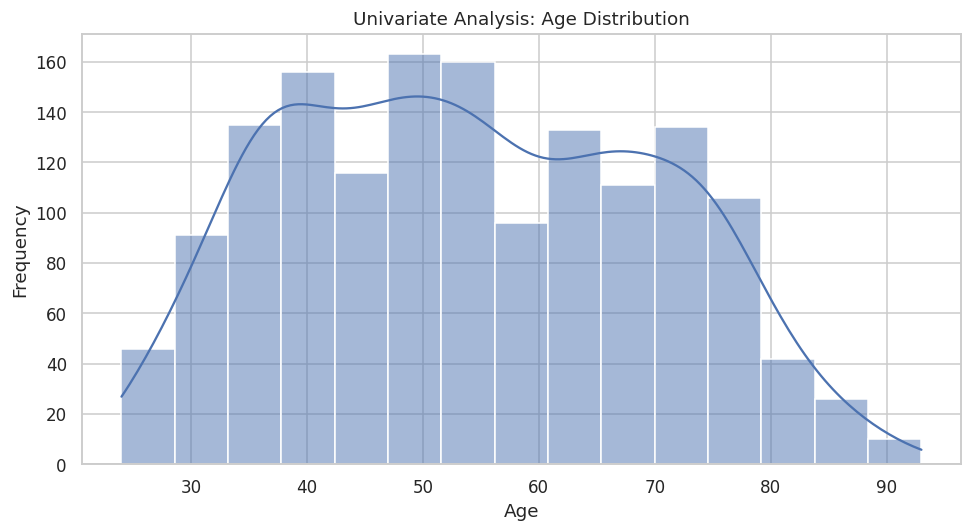

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(data=analysis_df, x="age", bins=15, kde=True)
plt.title("Univariate Analysis: Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Visualization 2 – Distribution of Political Knowledge


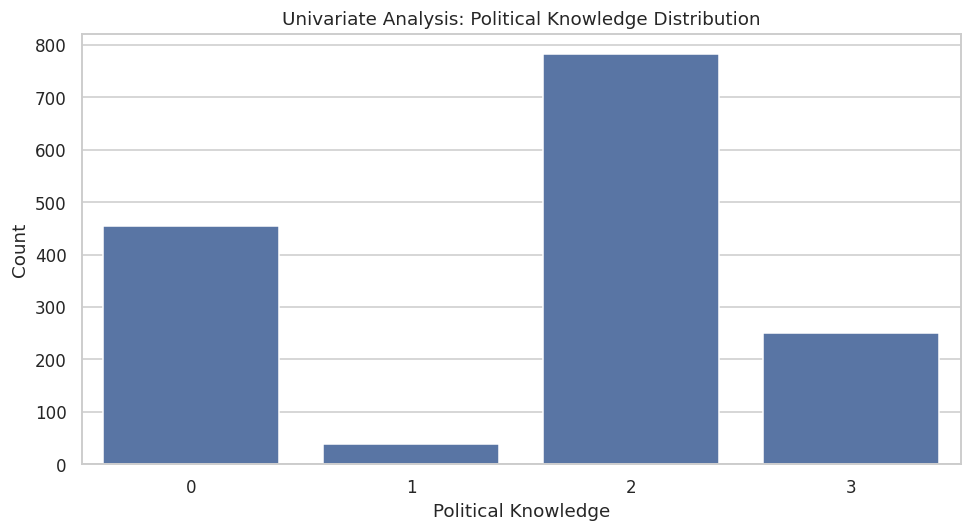

In [11]:
plt.figure(figsize=(9, 5))
sns.countplot(data=analysis_df, x="political_knowledge")
plt.title("Univariate Analysis: Political Knowledge Distribution")
plt.xlabel("Political Knowledge")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Visualization 3 – Vote Category Distribution


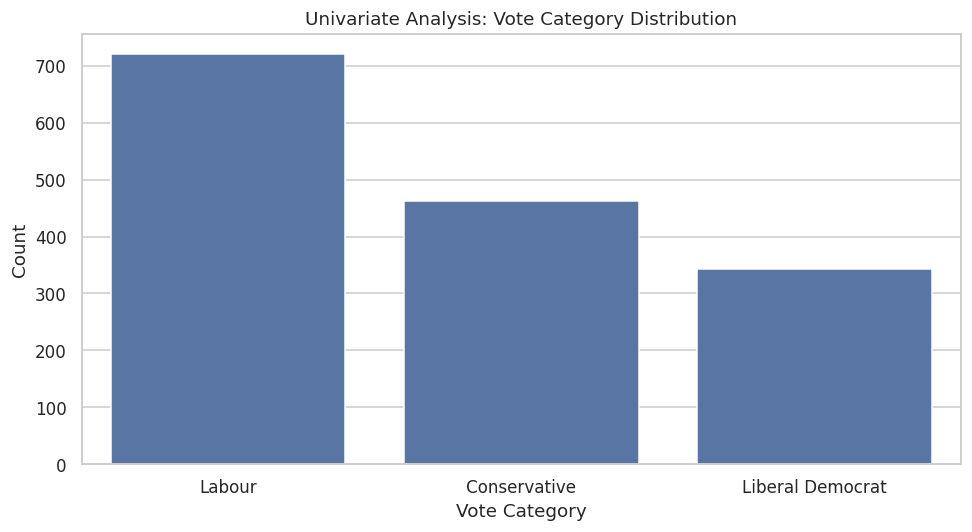

,Count
vote,
Labour,720
Conservative,462
Liberal Democrat,343


In [12]:
vote_counts = analysis_df["vote"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=vote_counts.index, y=vote_counts.values)
plt.title("Univariate Analysis: Vote Category Distribution")
plt.xlabel("Vote Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

display(vote_counts.to_frame("Count"))


# 11. Bivariate Analysis

Bivariate analysis examines the relationship between two variables.

Three visualizations are included:
1. Age and political knowledge
2. Age distribution across vote categories
3. Vote category distribution by gender


### Visualization 1 – Age vs Political Knowledge


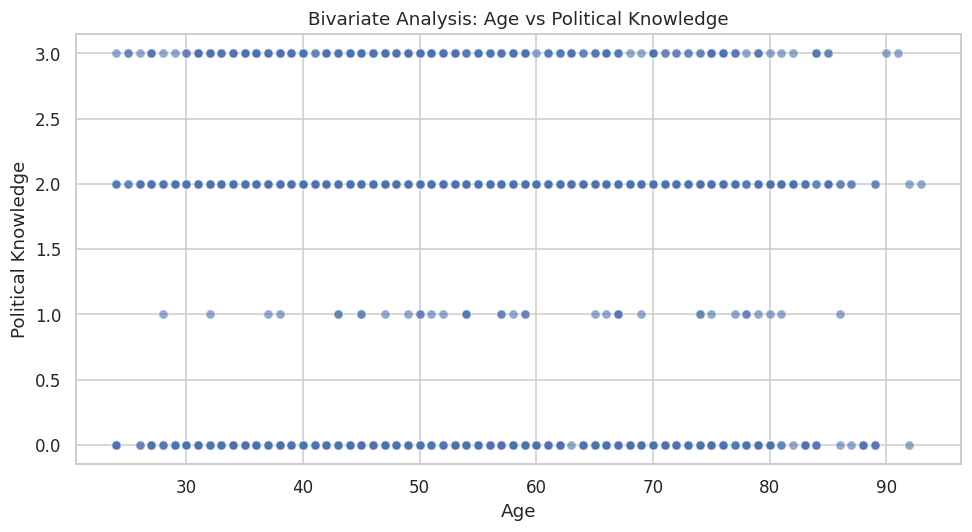

Pearson correlation between age and political knowledge: -0.0485


In [13]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=analysis_df,
    x="age",
    y="political_knowledge",
    alpha=0.6
)
plt.title("Bivariate Analysis: Age vs Political Knowledge")
plt.xlabel("Age")
plt.ylabel("Political Knowledge")
plt.tight_layout()
plt.show()

correlation = analysis_df[["age", "political_knowledge"]].corr().iloc[0, 1]
print(f"Pearson correlation between age and political knowledge: {correlation:.4f}")


### Visualization 2 – Age by Vote Category


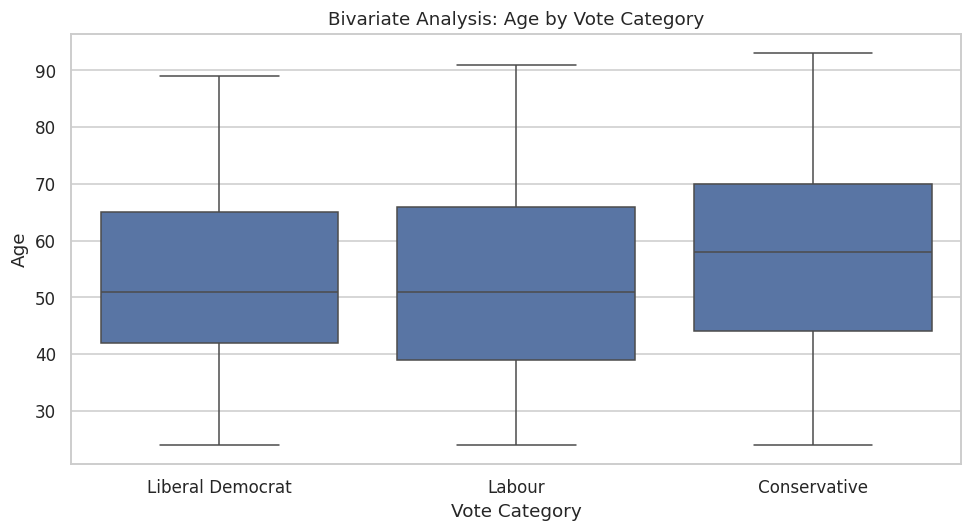

In [14]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=analysis_df,
    x="vote",
    y="age"
)
plt.title("Bivariate Analysis: Age by Vote Category")
plt.xlabel("Vote Category")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


### Visualization 3 – Vote Category by Gender


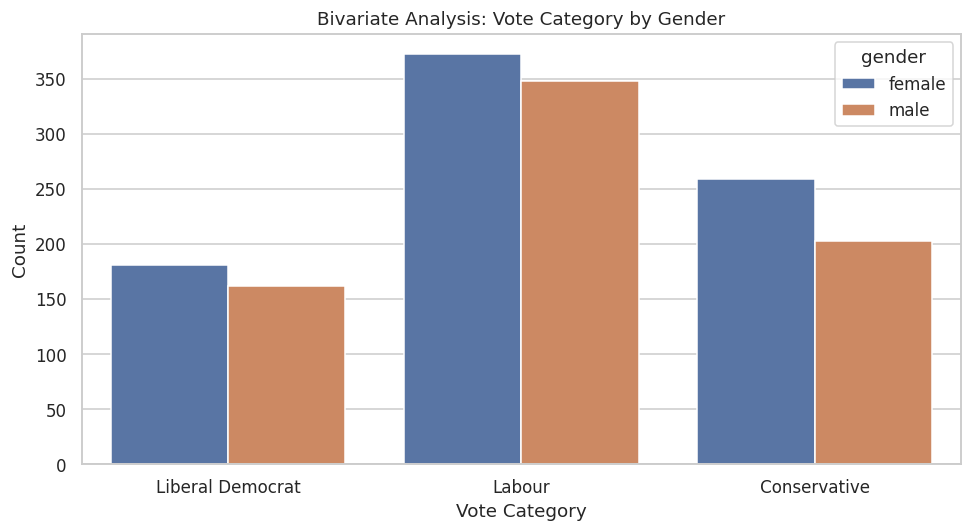

In [15]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=analysis_df,
    x="vote",
    hue="gender"
)
plt.title("Bivariate Analysis: Vote Category by Gender")
plt.xlabel("Vote Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# 12. Multivariate Analysis

Multivariate analysis examines three or more variables simultaneously.

Three visualizations are included:
1. Correlation heatmap
2. Pair plot
3. Age vs political knowledge with gender as a third variable


### Visualization 1 – Correlation Heatmap


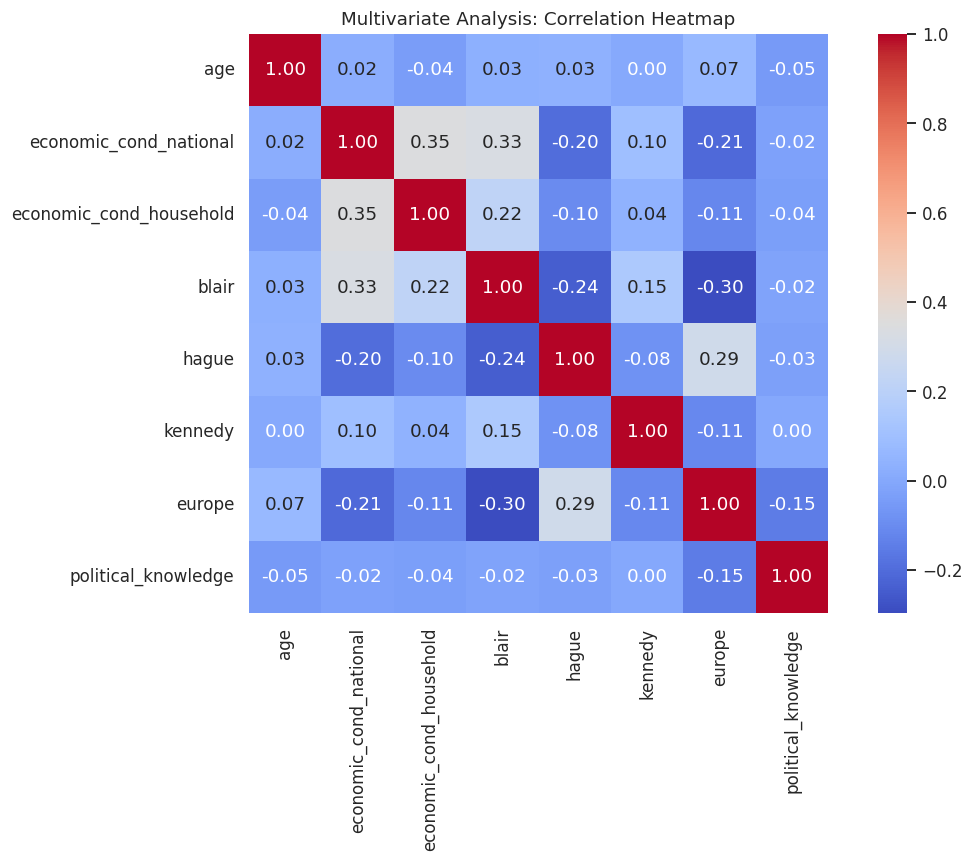

In [16]:
correlation_columns = [
    "age",
    "economic_cond_national",
    "economic_cond_household",
    "blair",
    "hague",
    "kennedy",
    "europe",
    "political_knowledge"
]

correlation_matrix = analysis_df[correlation_columns].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Multivariate Analysis: Correlation Heatmap")
plt.tight_layout()
plt.show()


### Visualization 2 – Pair Plot


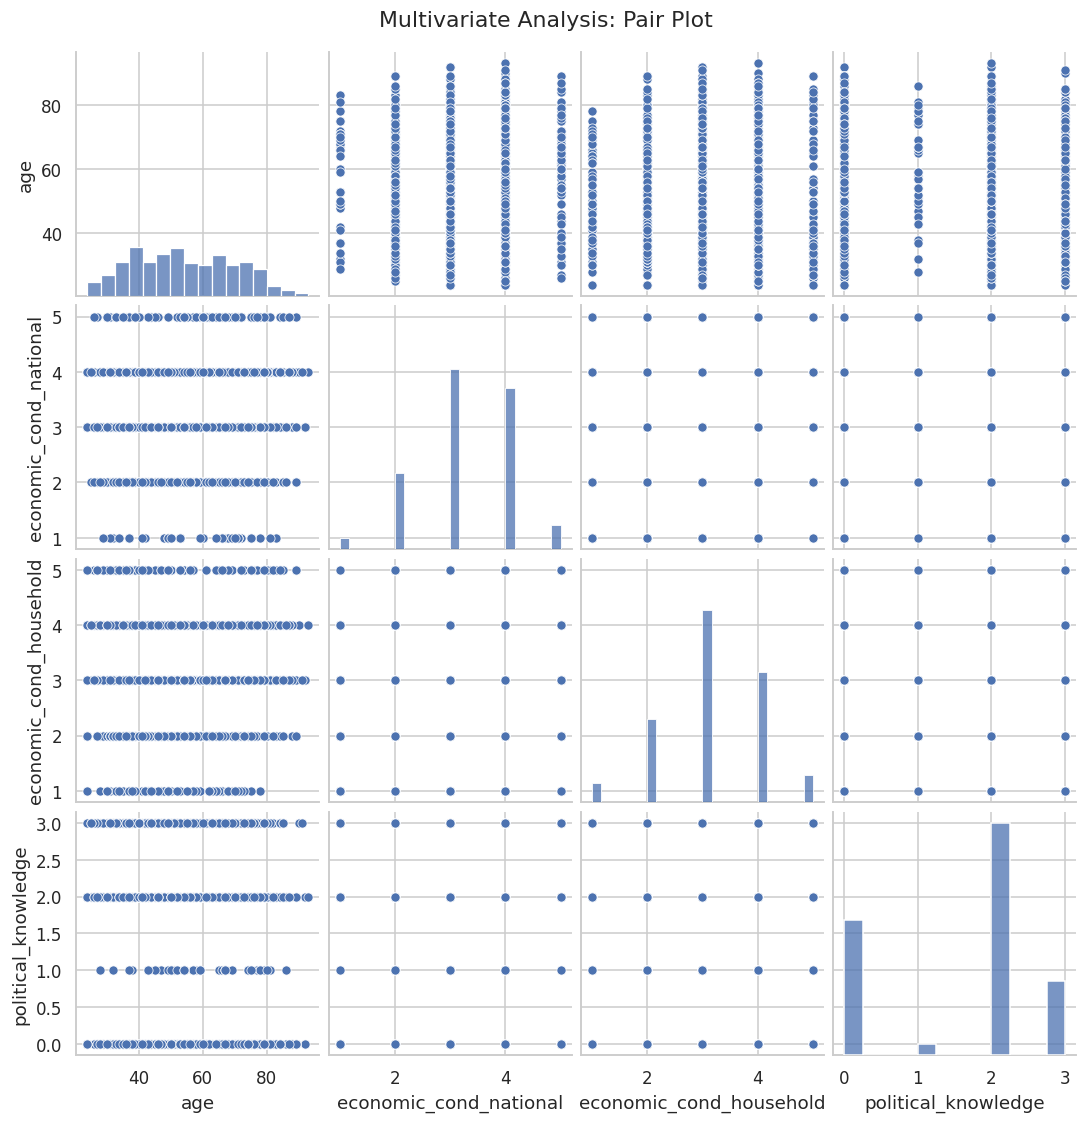

In [17]:
pair_columns = [
    "age",
    "economic_cond_national",
    "economic_cond_household",
    "political_knowledge"
]

pair_df = analysis_df[pair_columns].dropna()

sns.pairplot(pair_df)
plt.suptitle("Multivariate Analysis: Pair Plot", y=1.02)
plt.show()


### Visualization 3 – Age, Political Knowledge and Gender


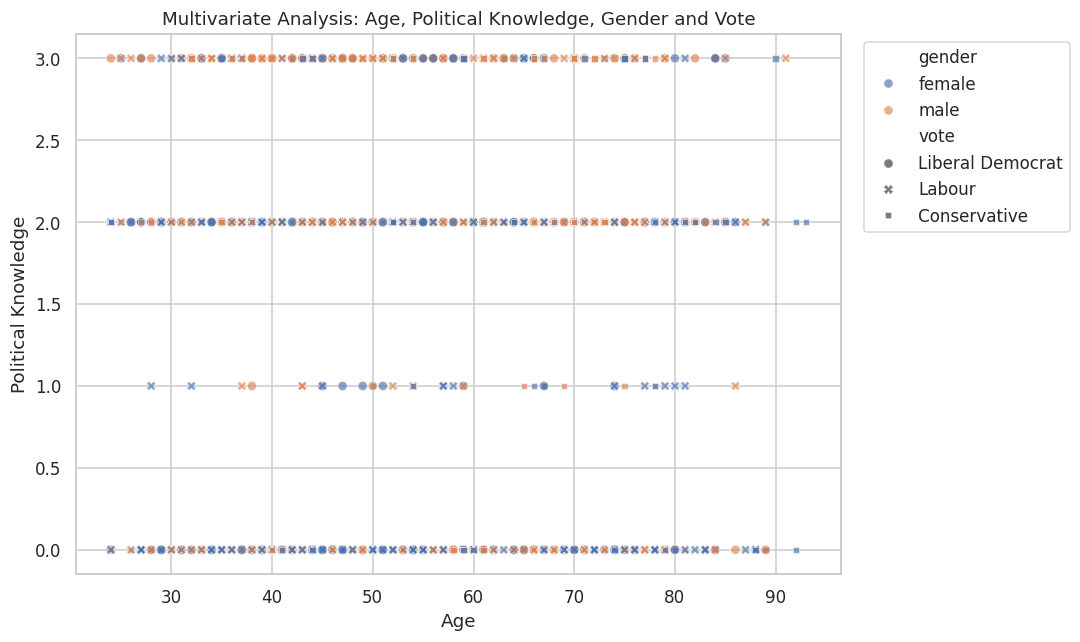

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=analysis_df,
    x="age",
    y="political_knowledge",
    hue="gender",
    style="vote",
    alpha=0.65
)

plt.title("Multivariate Analysis: Age, Political Knowledge, Gender and Vote")
plt.xlabel("Age")
plt.ylabel("Political Knowledge")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 13. Final Dataset Summary


In [19]:
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nTotal remaining missing values:", df_clean.isnull().sum().sum())
print("Total remaining duplicate rows:", df_clean.duplicated().sum())

print("\nAnalysis numeric variables:")
print(numeric_columns)

print("\nAnalysis categorical variables:")
print(categorical_columns)


Original dataset shape: (1525, 11)
Cleaned dataset shape: (1525, 11)

Total remaining missing values: 0
Total remaining duplicate rows: 0

Analysis numeric variables:
['age', 'economic_cond_national', 'economic_cond_household', 'blair', 'hague', 'kennedy', 'europe', 'political_knowledge']

Analysis categorical variables:
['vote', 'gender']


# 14. Conclusion

The BEPS dataset was successfully loaded and explored.

The Phase 1 requirements were completed through:
- Dataset loading and inspection
- Basic statistical analysis
- Missing-value identification and handling
- Duplicate checking and removal
- Column-name cleaning
- Appropriate data transformation
- Three univariate visualizations
- Three bivariate visualizations
- Three multivariate visualizations

The identifier column was excluded from analytical visualizations so that the EDA focuses on meaningful variables rather than row identifiers.


# Phase 2 – 1D and 2D Statistical Analysis

This section extends the Phase 1 EDA using the statistical analysis tasks demonstrated in the provided Lab Submission 7 PDF.

Included:
- 1D statistical summary
- Frequency and relative-frequency distributions
- Pie chart and bar chart
- Grouped frequency distribution
- Histogram
- Box plot and outlier identification
- 2D categorical analysis using contingency tables
- Row, column, and overall percentages
- Stacked and grouped bar charts
- Statistical characteristics by category
- Box plot and violin plot by category
- Pearson and Spearman correlation
- Scatter plot with regression line
- Correlation matrix and pairs plot
- K-means clustering
- Hierarchical clustering

The 3D statistical-analysis section is intentionally excluded.

## 15. Phase 2 – Libraries

In [20]:
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

phase2_df = df_clean.copy()

print("Phase 2 dataset shape:", phase2_df.shape)
display(phase2_df.head())

Phase 2 dataset shape: (1525, 11)


,rownames,vote,age,economic_cond_national,economic_cond_household,blair,hague,kennedy,europe,political_knowledge,gender
0,1,Liberal Democrat,43,3,3,4,1,4,2,2,female
1,2,Labour,36,4,4,4,4,4,5,2,male
2,3,Labour,35,4,4,5,2,3,3,2,male
3,4,Labour,24,4,2,2,1,3,4,0,female
4,5,Labour,41,2,2,1,1,4,6,2,male


## 16. 1D Statistical Analysis

### 16.1 Statistical Summary of Numerical Variables

In [21]:
numeric_data = phase2_df.select_dtypes(include=np.number).drop(columns=["rownames"], errors="ignore")

def summary_stats(x):
    x = x.dropna()
    return pd.Series({
        "Mean": x.mean(),
        "Median": x.median(),
        "Minimum": x.min(),
        "Maximum": x.max(),
        "Range": x.max() - x.min(),
        "Variance": x.var(),
        "Standard_Deviation": x.std(),
        "IQR": x.quantile(0.75) - x.quantile(0.25),
        "Skewness": skew(x),
        "Kurtosis": kurtosis(x, fisher=False)
    })

summary_table = numeric_data.apply(summary_stats).T
display(summary_table.round(4))

,Mean,Median,Minimum,Maximum,Range,Variance,Standard_Deviation,IQR,Skewness,Kurtosis
age,54.1823,53.0,24.0,93.0,69.0,246.8421,15.7112,26.0,0.1445,2.0523
economic_cond_national,3.2459,3.0,1.0,5.0,4.0,0.7761,0.8810,1.0,-0.2402,2.7409
economic_cond_household,3.1403,3.0,1.0,5.0,4.0,0.8648,0.9300,1.0,-0.1494,2.7904
blair,3.3344,4.0,1.0,5.0,4.0,1.3802,1.1748,2.0,-0.5349,1.9340
hague,2.7469,2.0,1.0,5.0,4.0,1.5146,1.2307,2.0,0.1519,1.6089
kennedy,3.1351,3.0,1.0,5.0,4.0,1.1707,1.0820,2.0,-0.3756,2.0196
europe,6.7285,6.0,1.0,11.0,10.0,10.8738,3.2975,6.0,-0.1358,1.7623
political_knowledge,1.5423,2.0,0.0,3.0,3.0,1.1736,1.0833,2.0,-0.4264,1.7834


### 16.2 Frequency and Relative-Frequency Distribution of Vote

In [22]:
vote_frequency = phase2_df["vote"].value_counts().sort_index()
vote_relative_frequency = vote_frequency / vote_frequency.sum()

vote_distribution = pd.DataFrame({
    "Category": vote_frequency.index,
    "Frequency": vote_frequency.values,
    "Relative_Frequency": vote_relative_frequency.values
})

display(vote_distribution.round(4))

,Category,Frequency,Relative_Frequency
0,Conservative,462,0.3030
1,Labour,720,0.4721
2,Liberal Democrat,343,0.2249


### 16.3 Pie Chart of Vote Distribution

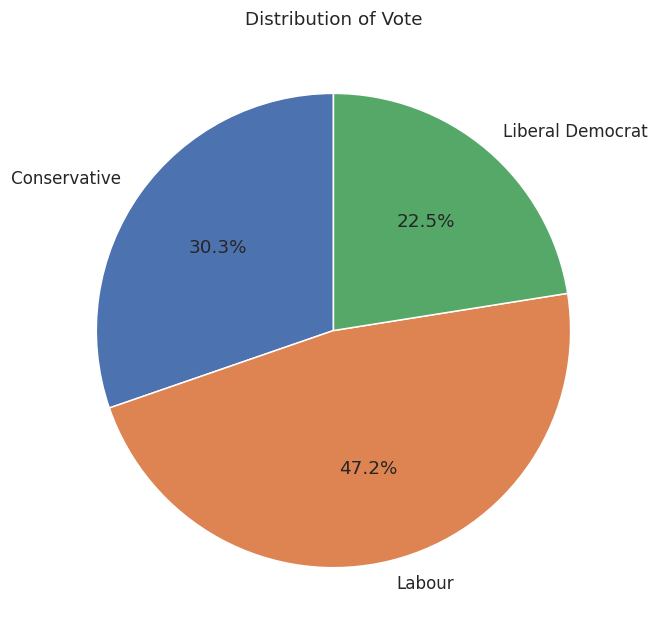

In [23]:
plt.figure(figsize=(7, 7))
plt.pie(
    vote_frequency.values,
    labels=vote_frequency.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Vote")
plt.show()

### 16.4 Frequency Distribution Bar Chart

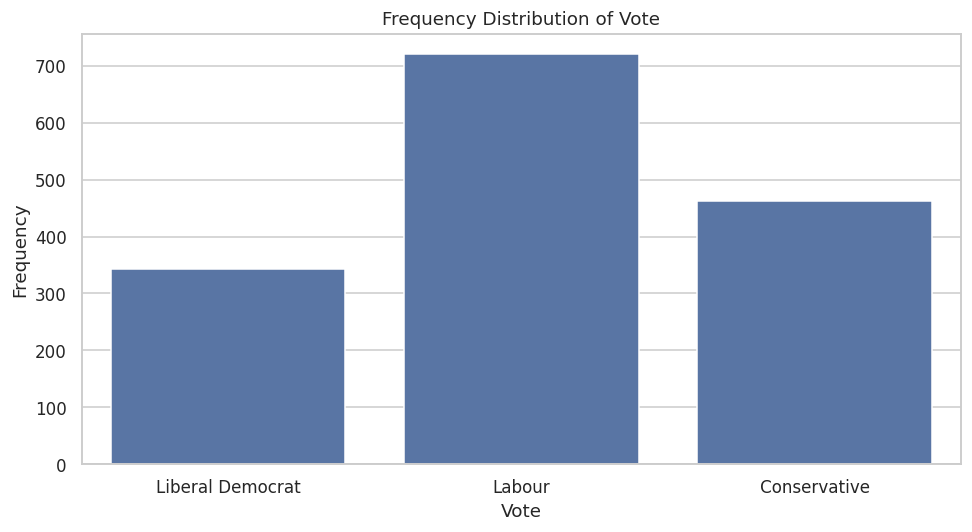

In [24]:
plt.figure(figsize=(9, 5))
sns.countplot(data=phase2_df, x="vote")
plt.title("Frequency Distribution of Vote")
plt.xlabel("Vote")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 16.5 Grouped Frequency and Relative-Frequency Distribution of Age

In [25]:
age_min = int(np.floor(phase2_df["age"].min()))
age_max = int(np.ceil(phase2_df["age"].max()))

age_breaks = list(range((age_min // 10) * 10, age_max + 11, 10))
if age_breaks[-1] <= age_max:
    age_breaks.append(age_breaks[-1] + 10)

phase2_df["age_group"] = pd.cut(
    phase2_df["age"],
    bins=age_breaks,
    right=False,
    include_lowest=True
)

age_frequency = phase2_df["age_group"].value_counts(sort=False)
age_relative_frequency = age_frequency / age_frequency.sum()

age_distribution = pd.DataFrame({
    "Age_Interval": age_frequency.index.astype(str),
    "Frequency": age_frequency.values,
    "Relative_Frequency": age_relative_frequency.values
})

display(age_distribution.round(4))

,Age_Interval,Frequency,Relative_Frequency
0,"[20, 30)",62,0.0407
1,"[30, 40)",277,0.1816
2,"[40, 50)",307,0.2013
3,"[50, 60)",298,0.1954
4,"[60, 70)",263,0.1725
5,"[70, 80)",240,0.1574
6,"[80, 90)",73,0.0479
7,"[90, 100)",5,0.0033


### 16.6 Histogram of Age

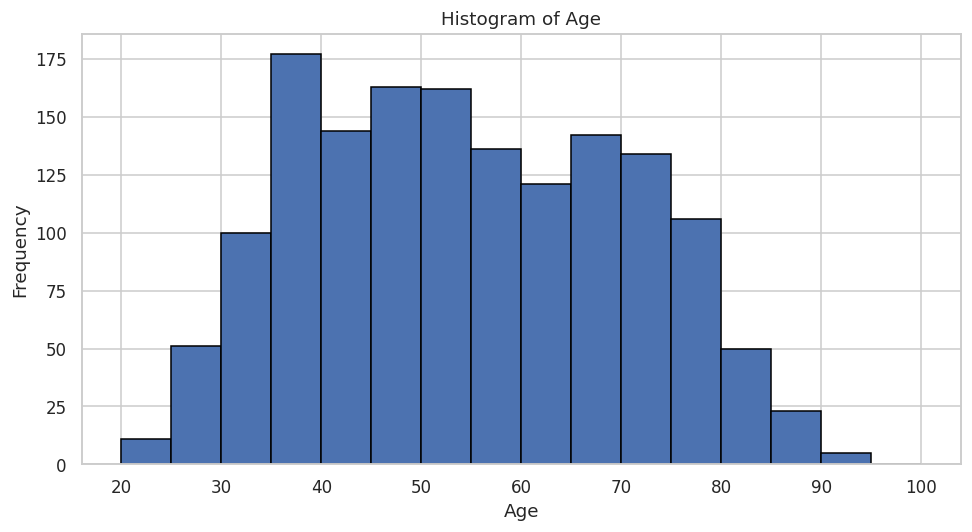

In [26]:
plt.figure(figsize=(9, 5))
plt.hist(phase2_df["age"].dropna(), bins=np.arange(20, 101, 5), edgecolor="black")
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 16.7 Box Plot and Outlier Identification

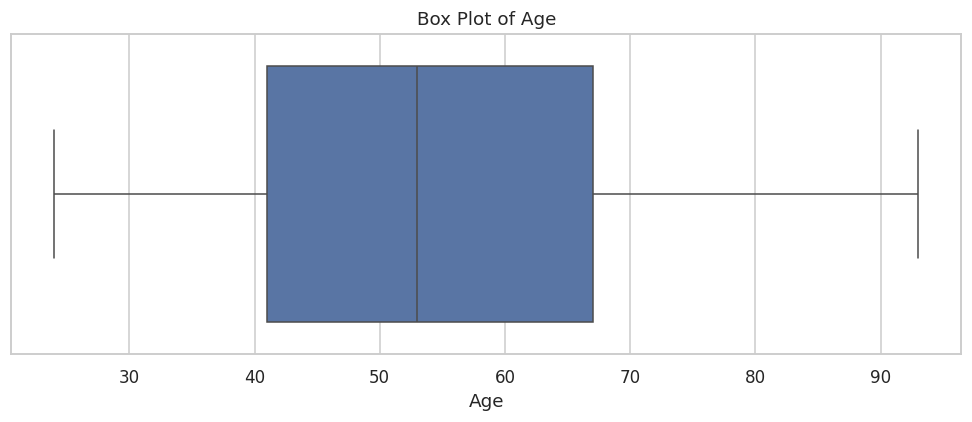

Potential age outliers:


,Age


In [27]:
plt.figure(figsize=(9, 4))
sns.boxplot(x=phase2_df["age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

q1 = phase2_df["age"].quantile(0.25)
q3 = phase2_df["age"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

age_outliers = phase2_df.loc[
    (phase2_df["age"] < lower_bound) | (phase2_df["age"] > upper_bound),
    "age"
]

print("Potential age outliers:")
display(age_outliers.to_frame(name="Age"))

## 17. 2D Statistical Analysis

### 17.1 Two Categorical Variables – Contingency Table

In [28]:
contingency_table = pd.crosstab(
    phase2_df["vote"],
    phase2_df["gender"]
)

display(contingency_table)

gender,female,male
vote,,
Conservative,259,203
Labour,372,348
Liberal Democrat,181,162


### 17.2 Row, Column, and Overall Percentages

In [29]:
row_percentages = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
column_percentages = contingency_table.div(contingency_table.sum(axis=0), axis=1) * 100
overall_percentages = contingency_table / contingency_table.values.sum() * 100

print("Row percentages:")
display(row_percentages.round(2))

print("Column percentages:")
display(column_percentages.round(2))

print("Overall percentages:")
display(overall_percentages.round(2))

Row percentages:


gender,female,male
vote,,
Conservative,56.06,43.94
Labour,51.67,48.33
Liberal Democrat,52.77,47.23


Column percentages:


gender,female,male
vote,,
Conservative,31.90,28.47
Labour,45.81,48.81
Liberal Democrat,22.29,22.72


Overall percentages:


gender,female,male
vote,,
Conservative,16.98,13.31
Labour,24.39,22.82
Liberal Democrat,11.87,10.62


### 17.3 Stacked Bar Plot

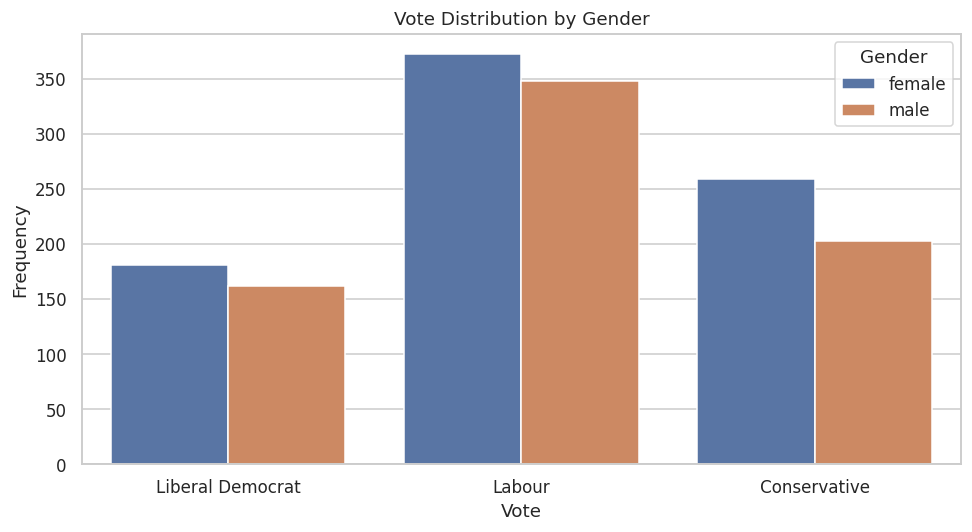

In [30]:
plt.figure(figsize=(9, 5))
sns.countplot(data=phase2_df, x="vote", hue="gender")
plt.title("Vote Distribution by Gender")
plt.xlabel("Vote")
plt.ylabel("Frequency")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

### 17.4 Grouped Bar Plot

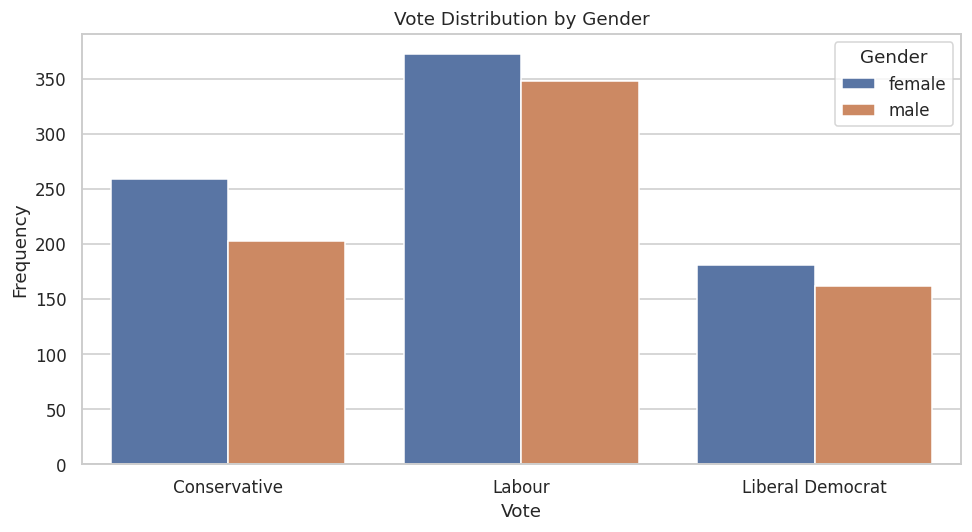

In [31]:
grouped_counts = phase2_df.groupby(["vote", "gender"]).size().reset_index(name="Frequency")

plt.figure(figsize=(9, 5))
sns.barplot(data=grouped_counts, x="vote", y="Frequency", hue="gender")
plt.title("Vote Distribution by Gender")
plt.xlabel("Vote")
plt.ylabel("Frequency")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

### 17.5 Statistical Characteristics by Category

In [32]:
age_by_vote = phase2_df.groupby("vote")["age"].agg(
    Mean="mean",
    Median="median",
    Standard_Deviation="std",
    Count="count"
)

display(age_by_vote.round(4))

,Mean,Median,Standard_Deviation,Count
vote,,,,
Conservative,56.8701,58.0,15.6058,462
Labour,53.0042,51.0,15.7973,720
Liberal Democrat,53.0350,51.0,15.2654,343


### 17.6 Box Plot of Age by Vote

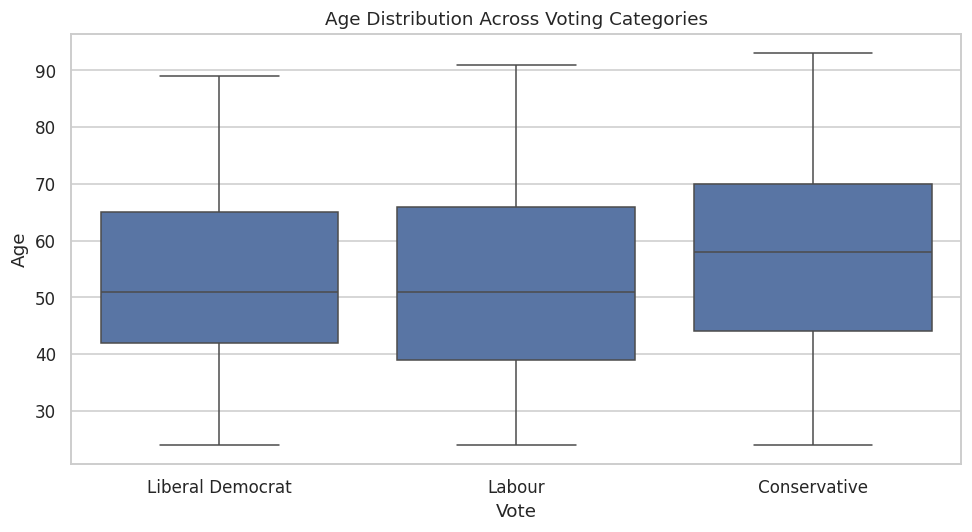

In [33]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=phase2_df, x="vote", y="age")
plt.title("Age Distribution Across Voting Categories")
plt.xlabel("Vote")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

### 17.7 Violin Plot of Age by Vote

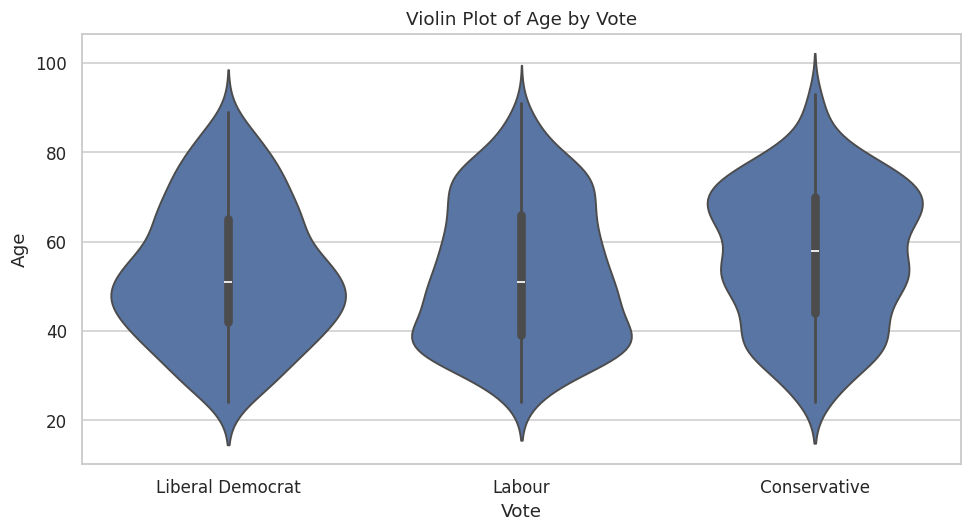

In [34]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=phase2_df, x="vote", y="age", inner="box")
plt.title("Violin Plot of Age by Vote")
plt.xlabel("Vote")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

### 17.8 Pearson and Spearman Correlation

In [35]:
pearson_correlation = phase2_df["age"].corr(
    phase2_df["europe"],
    method="pearson"
)

spearman_correlation = phase2_df["age"].corr(
    phase2_df["europe"],
    method="spearman"
)

print("Pearson correlation:", round(pearson_correlation, 6))
print("Spearman correlation:", round(spearman_correlation, 6))

Pearson correlation: 0.06888
Spearman correlation: 0.080039


### 17.9 Scatter Plot with Regression Line

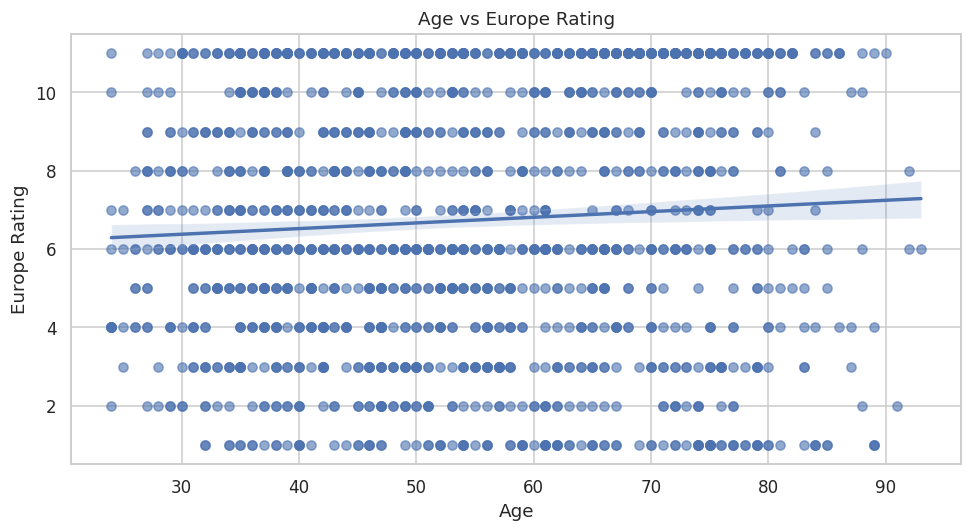

In [36]:
plt.figure(figsize=(9, 5))
sns.regplot(
    data=phase2_df,
    x="age",
    y="europe",
    scatter_kws={"alpha": 0.6},
    line_kws={}
)
plt.title("Age vs Europe Rating")
plt.xlabel("Age")
plt.ylabel("Europe Rating")
plt.tight_layout()
plt.show()

### 17.10 Correlation Matrix

In [37]:
selected_numeric = phase2_df[
    [
        "age",
        "economic_cond_national",
        "economic_cond_household",
        "blair",
        "hague",
        "kennedy",
        "europe",
        "political_knowledge"
    ]
]

correlation_matrix = selected_numeric.corr(method="pearson")
display(correlation_matrix.round(3))

,age,economic_cond_national,economic_cond_household,blair,hague,kennedy,europe,political_knowledge
age,1.000,0.019,-0.042,0.030,0.035,0.004,0.069,-0.048
economic_cond_national,0.019,1.000,0.346,0.327,-0.200,0.097,-0.209,-0.024
economic_cond_household,-0.042,0.346,1.000,0.215,-0.102,0.040,-0.115,-0.038
blair,0.030,0.327,0.215,1.000,-0.243,0.148,-0.296,-0.021
hague,0.035,-0.200,-0.102,-0.243,1.000,-0.080,0.287,-0.030
kennedy,0.004,0.097,0.040,0.148,-0.080,1.000,-0.110,0.001
europe,0.069,-0.209,-0.115,-0.296,0.287,-0.110,1.000,-0.152
political_knowledge,-0.048,-0.024,-0.038,-0.021,-0.030,0.001,-0.152,1.000


### 17.11 Correlation Heatmap

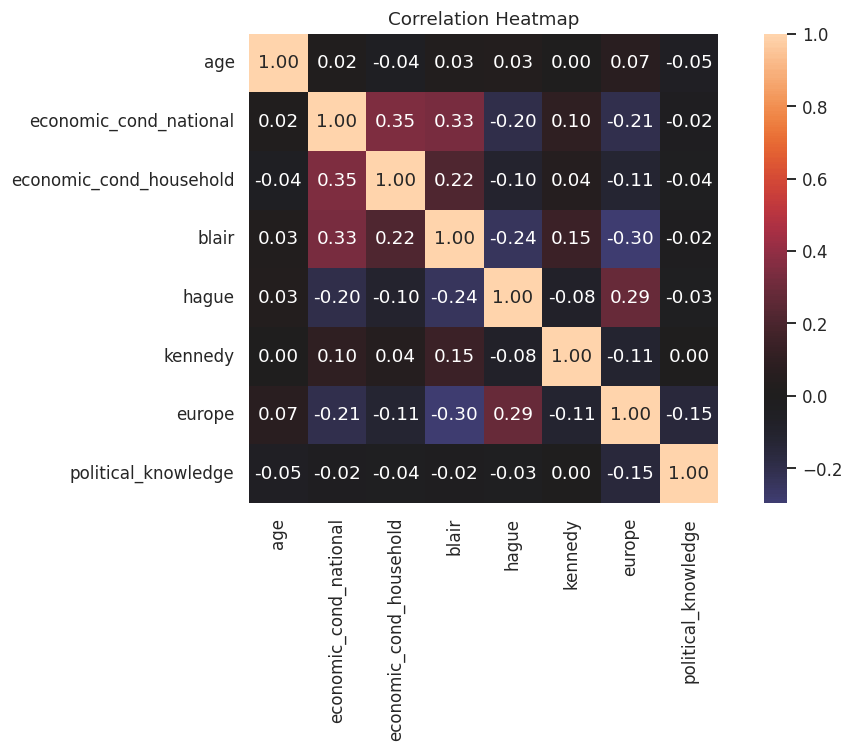

In [38]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    square=True
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 17.12 Pairs Plot of Numerical Variables

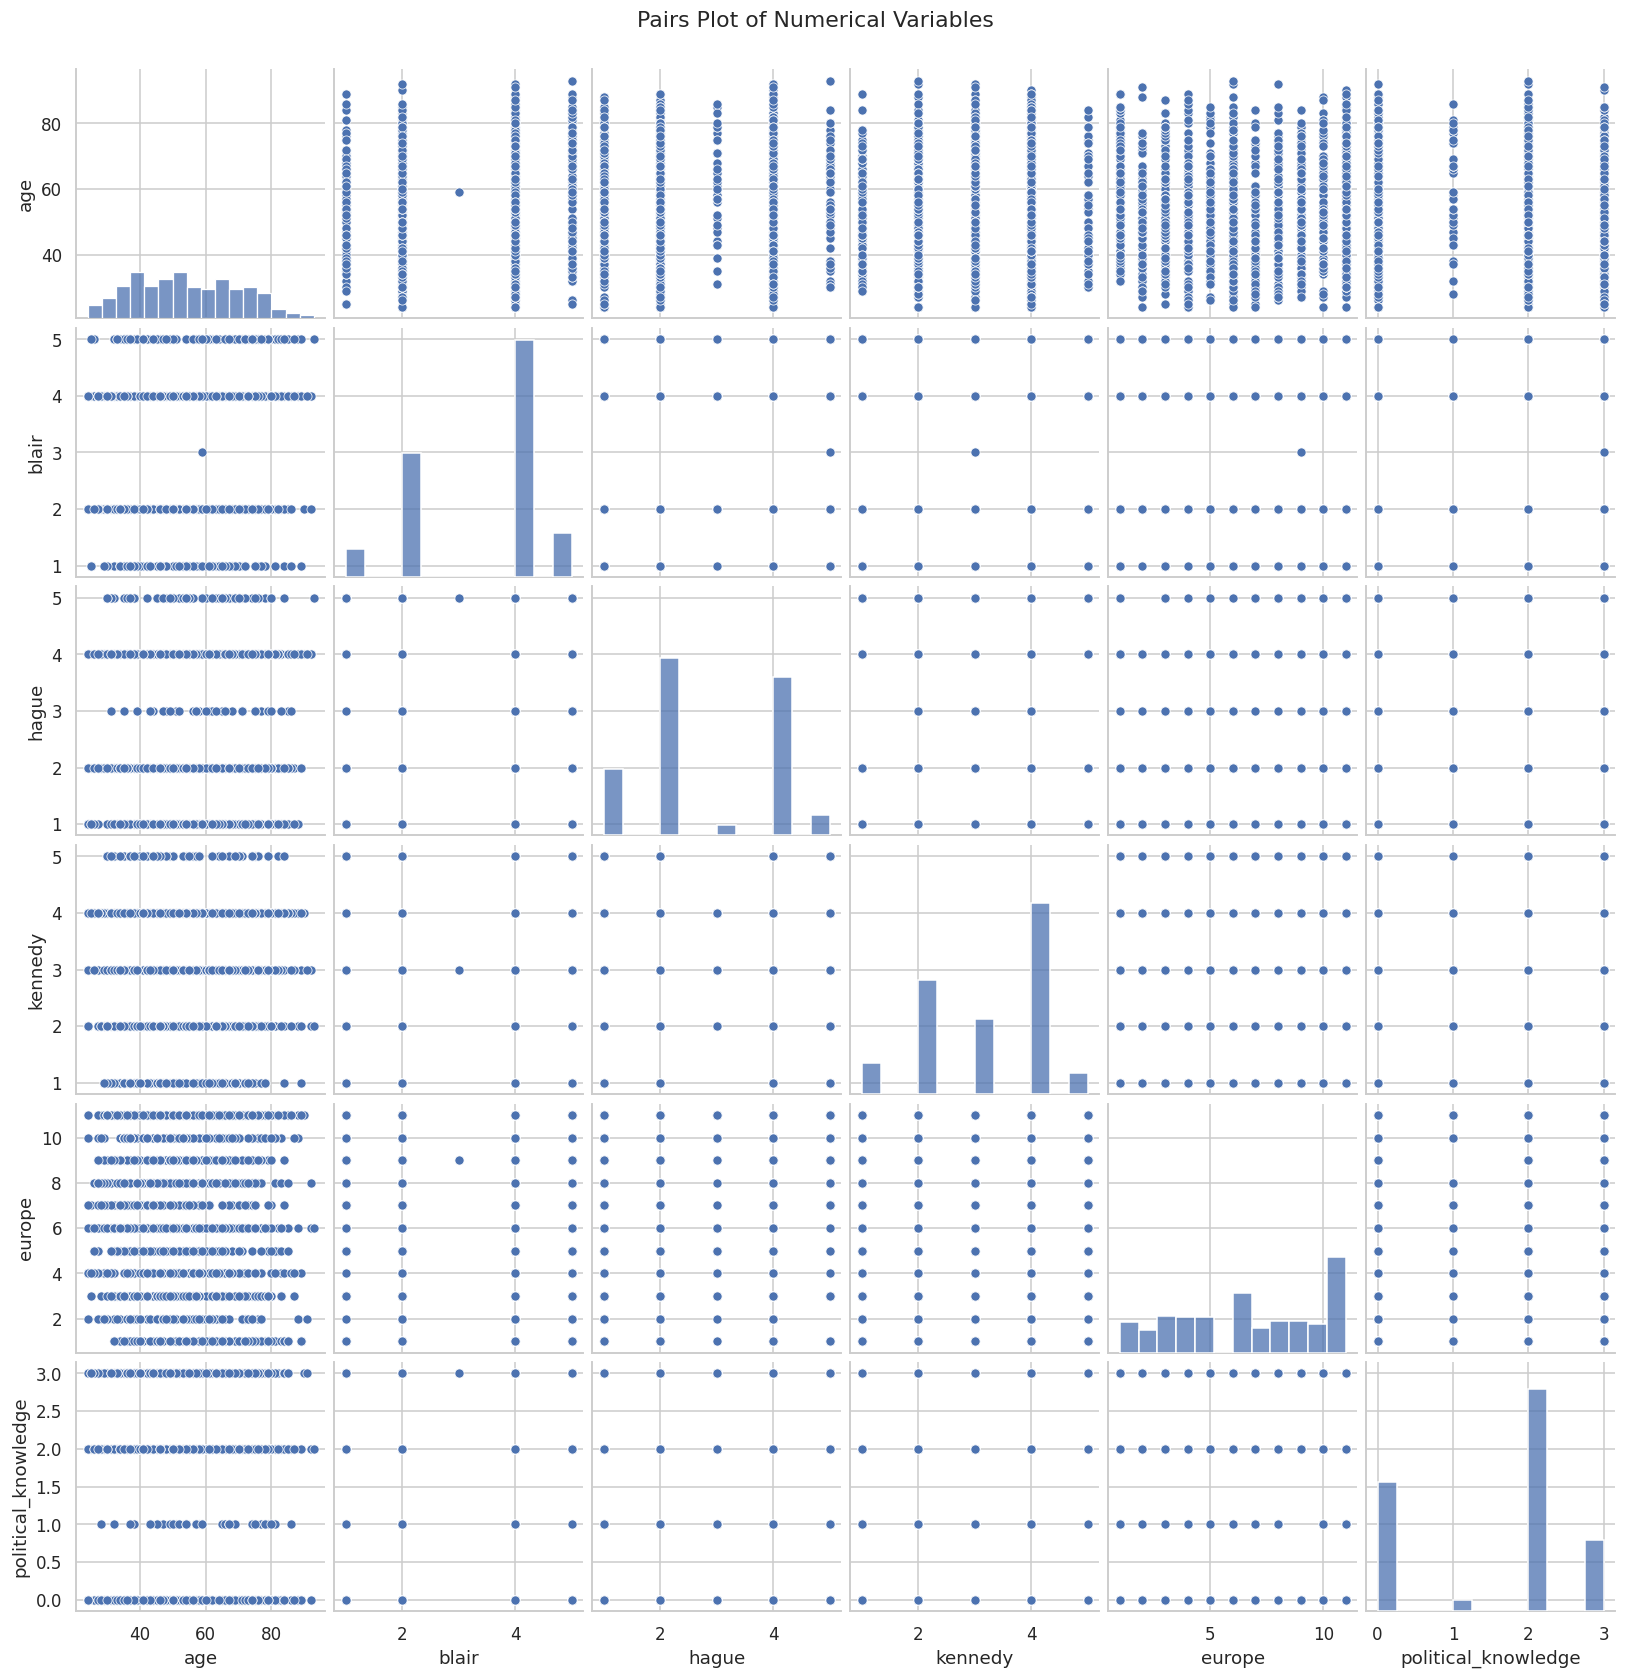

In [39]:
pairs_data = phase2_df[
    ["age", "blair", "hague", "kennedy", "europe", "political_knowledge"]
].dropna()

sns.pairplot(pairs_data)
plt.suptitle("Pairs Plot of Numerical Variables", y=1.02)
plt.show()

## 18. K-Means Clustering

In [40]:
cluster_features = phase2_df[
    [
        "age",
        "economic_cond_national",
        "economic_cond_household",
        "blair",
        "hague",
        "kennedy",
        "europe",
        "political_knowledge"
    ]
].dropna()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(cluster_scaled)

kmeans_result = cluster_features.copy()
kmeans_result["Cluster"] = kmeans_labels

display(kmeans_result.head())
print("Cluster counts:")
display(kmeans_result["Cluster"].value_counts().sort_index().to_frame("Count"))

,age,economic_cond_national,economic_cond_household,blair,hague,kennedy,europe,political_knowledge,Cluster
0,43,3,3,4,1,4,2,2,1
1,36,4,4,4,4,4,5,2,1
2,35,4,4,5,2,3,3,2,1
3,24,4,2,2,1,3,4,0,2
4,41,2,2,1,1,4,6,2,0


Cluster counts:


,Count
Cluster,
0,514
1,611
2,400


### 18.1 K-Means Cluster Visualization

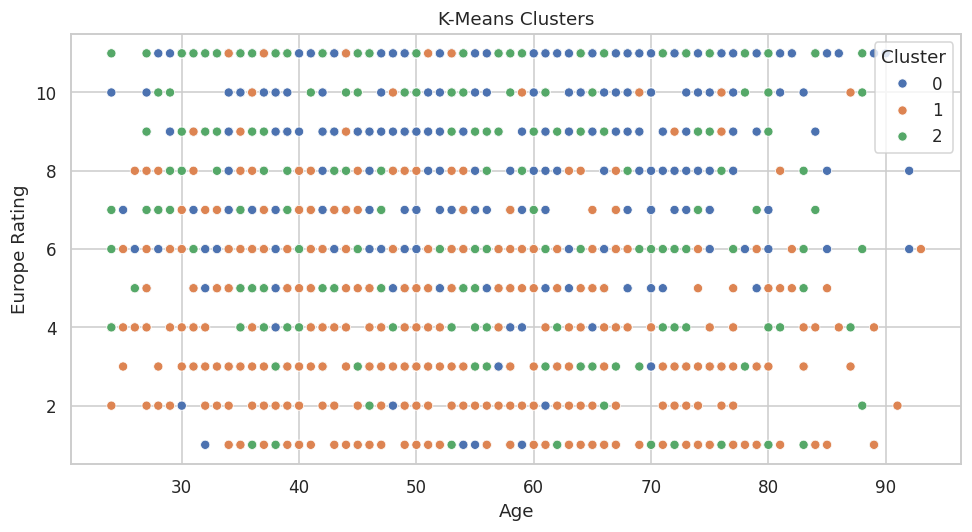

In [41]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=kmeans_result,
    x="age",
    y="europe",
    hue="Cluster",
    palette="deep"
)
plt.title("K-Means Clusters")
plt.xlabel("Age")
plt.ylabel("Europe Rating")
plt.tight_layout()
plt.show()

## 19. Hierarchical Clustering

In [42]:
hierarchical_model = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical_model.fit_predict(cluster_scaled)

hierarchical_result = cluster_features.copy()
hierarchical_result["Cluster"] = hierarchical_labels

display(hierarchical_result.head())

print("Hierarchical cluster counts:")
display(
    hierarchical_result["Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

,age,economic_cond_national,economic_cond_household,blair,hague,kennedy,europe,political_knowledge,Cluster
0,43,3,3,4,1,4,2,2,0
1,36,4,4,4,4,4,5,2,0
2,35,4,4,5,2,3,3,2,0
3,24,4,2,2,1,3,4,0,1
4,41,2,2,1,1,4,6,2,2


Hierarchical cluster counts:


,Count
Cluster,
0,595
1,479
2,451


### 19.1 Hierarchical Clustering Dendrogram

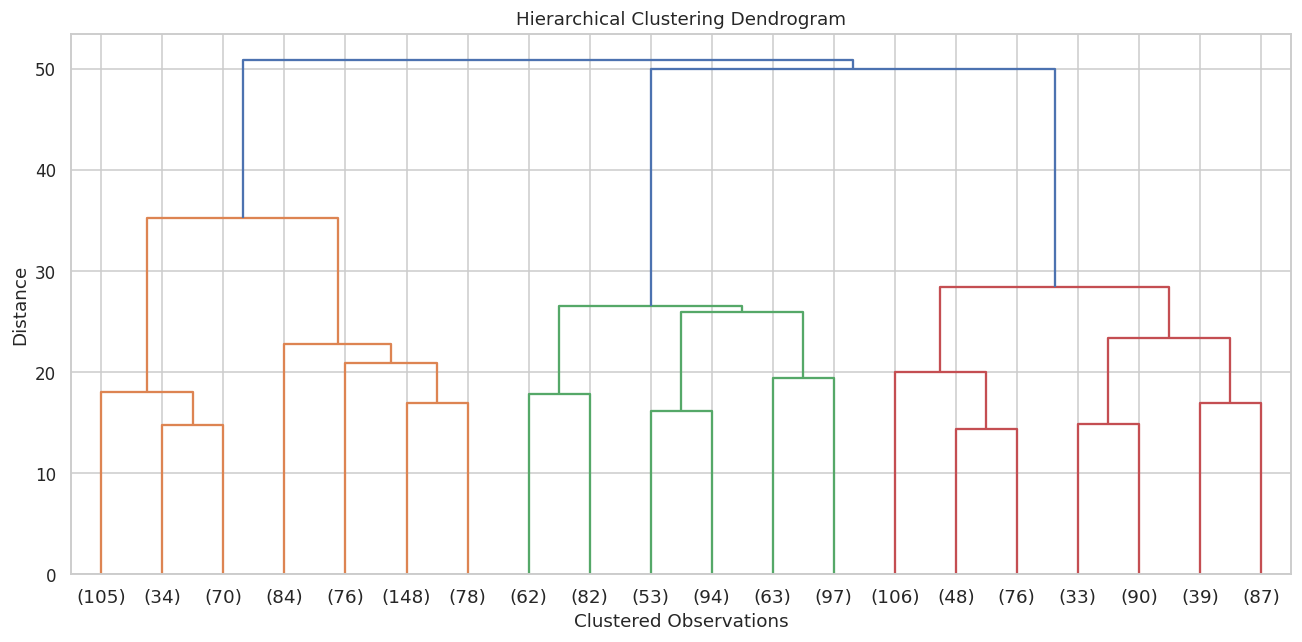

In [43]:
linkage_matrix = linkage(cluster_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clustered Observations")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## 20. Phase 2 Summary


Included:
- Numerical statistical summary
- Frequency and relative-frequency distributions
- Pie chart
- Bar chart
- Grouped age distribution
- Histogram
- Box plot and outlier identification
- Contingency table
- Row, column, and overall percentages
- Stacked and grouped bar charts
- Statistical characteristics by category
- Box plot and violin plot
- Pearson and Spearman correlation
- Scatter plot with regression line
- Correlation matrix and heatmap
- Pairs plot
- K-means clustering
- Hierarchical clustering

